# 01 · The System, and What We Can Measure

*Learning to Identify New Dynamical Systems from a Few Experiments* is a nine-chapter course built
from the author's own research tutorial on few-shot system identification. Engineers rarely meet a
dynamical system that is completely new: a new motor resembles motors characterised before, a new
robot joint behaves like other joints of the same series, a new patient's heart rhythm varies around
patterns seen in many other patients. **Foundation models for dynamical systems** aim to exploit
exactly this: learn, from data of *many* systems, what systems of a kind have in common, so a *new*
system can be understood, predicted and controlled from very little data.

This course builds the smallest version of that idea in which every step can be inspected and
tested. We work with a family of nonlinear oscillators and answer, one chapter at a time, the
questions that also drive the large-scale research problem:

| Chapter | Question | Tool |
|---|---|---|
| 01 | What is the system, and what can we actually measure? | simulation, partial observation |
| 02 | How well can we identify one system from scratch? | output-error least squares |
| 03 | What do many systems have in common? | pretraining a low-dimensional family |
| 04 | Can the shared knowledge identify a new system from little data? | few-shot Bayesian adaptation |
| 05 | When is pretraining worth it? | data-budget study |
| 06 | Can we choose *which* experiment to run? | Fisher information, optimal design |
| 07 | How do we notice that the shared knowledge does not fit? | misfit-based detection |
| 08 | Does a better model give better control? | model-based feedforward |
| 09 | Where does this go next? | summary and open questions |

Everything is self-contained (NumPy, SciPy, Matplotlib) and each chapter runs in a few seconds to a
couple of minutes on a laptop. All randomness is seeded; every number quoted in the text is
recomputed when you run the notebook.

---
## 1. A family of nonlinear oscillators

Our "systems" are carts attached to a nonlinear spring and a damper, pushed by a force-limited
actuator. With position $q$ and velocity $v$,

$$
\dot q = v, \qquad
\dot v = -k\,q \;-\; d\,v \;+\; b\,\varphi(u) \;-\; \alpha\,q^3 .
$$

| Symbol | Meaning |
|---|---|
| $k$ | linear stiffness (sets the natural frequency $\omega_n\approx\sqrt{k}$) |
| $d$ | damping (sets how sharp the resonance is) |
| $b$ | input gain (how strongly the actuator pushes) |
| $\alpha$ | hardening of the spring at large deflection |
| $\varphi(u)=0.3\tanh(u/0.6)$ | a saturating actuator: commands beyond $\pm1$ gain little extra force |

We collect the four physical coefficients in $\eta=[k,\ d,\ b,\ \alpha]^\top$.

**What makes it a *family*.** Every system shares the equation above but has its own $\eta$. In the
simulator, the coefficients of a system are generated from two hidden "design" variables
$c\in[-1,1]^2$ (think: spring material and cart mass), plus small individual deviations:

$$
\eta = \eta_0 + M c + \epsilon, \qquad \epsilon \sim \mathcal N(0, \operatorname{diag}(0.015, 0.004, 0.008, 0.04)^2).
$$

The learner is **never** told $\eta_0$, $M$, $c$ or even that the family is two-dimensional.
It must discover this structure from data.

**What makes it realistic.** The true systems also contain effects the learner's model will not have:
a weak quintic spring term $-\gamma q^5$, a small constant force bias $r$, and a *coloured* random
disturbance $w_t$ (e.g. vibrations) acting on the cart. The actuator acts with a one-sample delay.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import dynutils

dynutils.set_style()
rng = np.random.default_rng(dynutils.SEED)
COLOR = dynutils.COLOR

In [2]:
DT = 0.1                                  # sampling time [s]
X0 = np.array([0.2, 0.0])                 # every experiment starts at rest, deflected by 0.2
NAMES = ["k", "d", "b", "α"]

# Hidden family structure: known to the simulator only.
_ETA0 = np.array([1.20, 0.32, 0.90, 1.00])
_M = np.array([[0.55, 0.12], [0.07, 0.11], [0.16, -0.09], [0.30, 0.45]])
_SIGMA_Y, _SIGMA_W, _RHO = 0.01, 0.01, 0.8     # sensor noise, disturbance strength, disturbance colour


def actuator(u):
    return 0.3 * np.tanh(np.asarray(u) / 0.6)


def sample_system(rng, context=None):
    # Draw a new member of the family (the 'secret' ground truth).
    c = rng.uniform(-1, 1, 2) if context is None else np.asarray(context, float)
    eta = _ETA0 + _M @ c + rng.normal(scale=[0.015, 0.004, 0.008, 0.04])
    return dict(eta=eta, context=c,
                gamma=0.035 + 0.012 * rng.uniform(),        # unmodelled quintic spring
                bias=0.006 * c[0] + 0.002 * rng.normal())   # unmodelled force bias


def simulate(system, u, rng, noise=True):
    # True plant. Returns (true positions, noisy position measurements), length len(u)+1.
    k, d, b, a = system["eta"]
    u_delayed = np.r_[0.0, np.asarray(u, float)[:-1]]
    (q, v), w = X0, 0.0
    qs = [q]
    for ut in u_delayed:
        if noise:
            w = _RHO * w + _SIGMA_W * rng.normal()
        acc = (-k * q - d * v + b * actuator(ut) - a * q**3
               - system["gamma"] * q**5 + system["bias"] + w)
        v = v + DT * acc                  # semi-implicit Euler
        q = q + DT * v
        qs.append(q)
    qs = np.array(qs)
    y = qs + (_SIGMA_Y * rng.normal(size=qs.size) if noise else 0.0)
    return qs, y


def multisine(T, rng, n=3, fmin=0.02, fmax=0.8):
    # Random admissible input: a sum of n sines with random frequencies [Hz] and phases, peak 1.
    t = DT * np.arange(T)
    f = np.exp(rng.uniform(np.log(fmin), np.log(fmax), n))
    s = sum(np.sin(2 * np.pi * fi * t + rng.uniform(0, 2 * np.pi)) for fi in f)
    return s / np.abs(s).max()

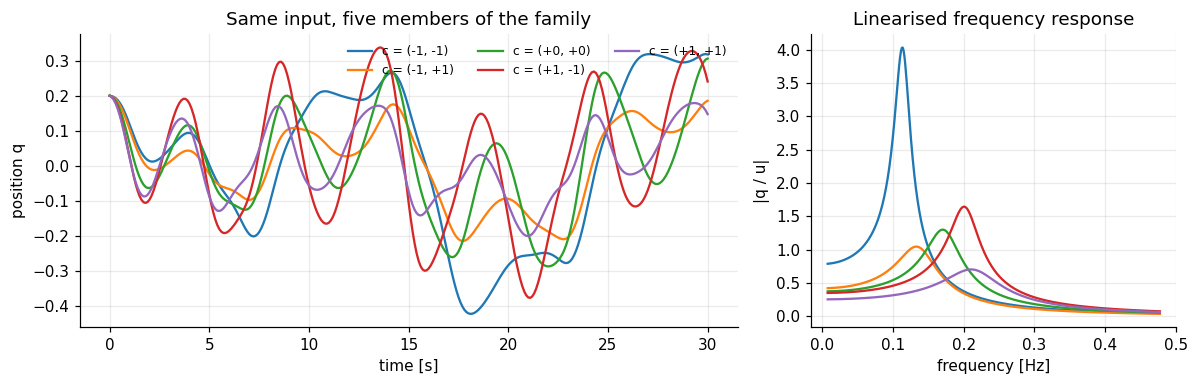

In [3]:
systems = [sample_system(rng, c) for c in [(-1, -1), (-1, 1), (0, 0), (1, -1), (1, 1)]]
u_demo = multisine(300, rng, n=5)
t = DT * np.arange(301)
omega = np.linspace(0.05, 3, 400)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw=dict(width_ratios=[1.8, 1]))
for s in systems:
    q, _ = simulate(s, u_demo, rng, noise=False)
    ax1.plot(t, q, lw=1.5, label=f"c = ({s['context'][0]:+.0f}, {s['context'][1]:+.0f})")
    k, d, b, _ = s["eta"]
    ax2.plot(omega / (2 * np.pi), 0.5 * b / np.abs(k - omega**2 + 1j * d * omega), lw=1.5)
ax1.set(xlabel="time [s]", ylabel="position q", title="Same input, five members of the family")
ax1.legend(ncol=3, fontsize=8, loc="upper right")
ax2.set(xlabel="frequency [Hz]", ylabel="|q / u|", title="Linearised frequency response")
plt.tight_layout(); plt.show()

The same input produces clearly different motions. The frequency responses show why: the members
differ in resonance frequency (roughly 0.1–0.25 Hz, i.e. a period of 4–10 s), in how peaked
the resonance is, and in gain. A model of the *average* system will therefore mispredict most
individual systems. Keep the resonance band in mind; it returns in chapter 06.

---
## 2. What the learner sees, and what it does not

In the laboratory, the learner can **choose the input** $u_t$ and **read a position sensor**
$y_t = q_t + \nu_t$. It does *not* see the velocity, the disturbance, or the coefficients.

| Quantity | Simulator knows | Learner receives |
|---|:---:|:---:|
| coefficients $\eta$, hidden context $c$ | ✔ | ✘ |
| input $u_t$ | ✔ | ✔ (it chooses it) |
| position $q_t$ | ✔ | only noisy $y_t$ |
| velocity $v_t$, disturbance $w_t$ | ✔ | ✘ |
| quintic term, bias | ✔ | ✘ (not even in its model) |

The learner's model is the equation above **without** the unknown extra effects:

$$
\hat v_{t+1} = \hat v_t + \Delta t\,\big(-k\hat q_t - d\hat v_t + b\,\varphi(u_{t-1}) - \alpha \hat q_t^3\big),
\qquad \hat q_{t+1} = \hat q_t + \Delta t\,\hat v_{t+1}.
$$

This mismatch is deliberate. Real models are always wrong in some way, and a method is only
interesting if it degrades gracefully when that happens.

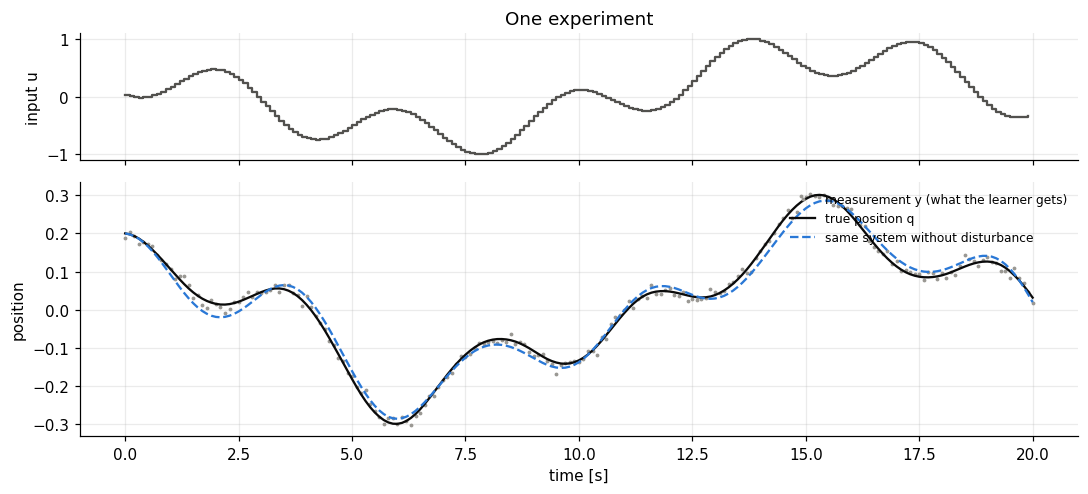

RMSE(true position, disturbance-free response) over this experiment: 0.0165 (sensor noise sd alone: 0.01)


In [4]:
s = systems[2]
u = multisine(200, rng)
q_true, y = simulate(s, u, rng)
q_clean, _ = simulate(s, u, rng, noise=False)
t = DT * np.arange(201)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4.6), sharex=True, gridspec_kw=dict(height_ratios=[1, 2]))
ax1.step(t[:-1], u, where="post", color=COLOR["reference"], lw=1.5)
ax1.set(ylabel="input u", title="One experiment")
ax2.plot(t, y, ".", ms=3, color=COLOR["measured"], label="measurement y (what the learner gets)")
ax2.plot(t, q_true, color=COLOR["truth"], lw=1.5, label="true position q")
ax2.plot(t, q_clean, "--", color=COLOR["context"], lw=1.5, label="same system without disturbance")
ax2.set(xlabel="time [s]", ylabel="position"); ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()
print(f"RMSE(true position, disturbance-free response) over this experiment: "
      f"{np.sqrt(np.mean((q_true - q_clean) ** 2)):.4f} (sensor noise sd alone: 0.01)")


The gap between the solid and the dashed line is caused by the coloured disturbance alone. No model
can predict it in advance, so we will judge models by how well they predict the system's
**disturbance-free response** to a new input: this measures the quality of the *model*, not our luck
with the noise.

---
## Exercises

### Exercise 1: A stiffer, less damped corner of the family
Draw 200 random contexts `c` uniformly in $[-1,1]^2$, compute the corresponding $\eta$ with
`sample_system(rng, c)`, and scatter the resulting natural frequency $\sqrt{k}$ against the damping
ratio $d/(2\sqrt{k})$. Which corner of $c$-space gives the most lightly damped, highest-frequency
systems?

<details><summary>Solution</summary>

```python
cs = rng.uniform(-1, 1, (200, 2))
etas = np.array([sample_system(rng, c)["eta"] for c in cs])
k, d = etas[:, 0], etas[:, 1]
wn, zeta = np.sqrt(k), d / (2 * np.sqrt(k))
plt.scatter(wn, zeta, c=cs[:, 0], cmap="viridis", s=12)
plt.colorbar(label="c1"); plt.xlabel("natural frequency ωₙ"); plt.ylabel("damping ratio ζ")
```
Both $k$ and $d$ load mostly onto $c_1$ (row 1 of $M$ is $[0.55, 0.12]$, row 2 is $[0.07, 0.11]$), so
$c_1 \to +1$ gives the stiffest, highest-frequency systems, and since $k$ grows faster than $d$ along
$c_1$, those same systems end up the most lightly damped.
</details>

### Exercise 2: How much does the disturbance matter?
For one system, simulate the same input 50 times with `noise=True` and once with `noise=False`.
Plot the disturbance-free trajectory against the envelope (min/max across the 50 noisy runs). At
what fraction of the 20 s experiment does the spread exceed the sensor noise alone ($\sigma_y=0.01$)?

<details><summary>Solution</summary>

```python
s = sample_system(rng); u = multisine(200, rng)
clean, _ = simulate(s, u, rng, noise=False)
noisy = np.array([simulate(s, u, rng)[0] for _ in range(50)])
spread = noisy.std(axis=0)
print(f"fraction of samples with spread > sensor noise: {(spread > 0.01).mean():.0%}")
```
The disturbance is coloured (ρ=0.8), so it builds up over a run rather than averaging out sample by
sample; the spread across repeats is usually well above 0.01 for most of the trajectory, confirming
that the gap in the figure above is dominated by the disturbance, not by sensor noise.
</details>

---
## Key takeaways

- A "family" here means a shared nonlinear equation with a two-dimensional hidden design space
  $c$; the physical coefficients $\eta$ are a noisy affine function of $c$.
- The learner only ever sees a chosen input and a noisy position measurement, never the velocity,
  the disturbance, or the coefficients, and its model omits two effects the true systems have.
- Because no model can be perfect here, every chapter judges models by predicting the
  **disturbance-free response to a new input**, which isolates model quality from measurement luck.

**Next:** *02 · Identifying One System From Scratch*. The classical baseline: fit all four
coefficients of one system from one experiment, and see where it succeeds and where it struggles.